# Sección 9 — Enfoque B: $\mathcal{G}(p,c)$ cruzado por k-pairs

Implementa la fórmula definida en el MD 9:
$$\mathcal{G}(p,\,c) = \left(\bigcup_{k=1}^{4} \mathcal{G}_k(p,c)\right) \setminus \{\emptyset\}$$

El objetivo es recuperar el GUID correcto para cada uno de los **36 eventos centinela k=1**,
consultando los cuatro k-pairs en lugar de solo k=1 (Enfoque A).

## Setup

In [18]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 80)
pd.set_option('display.max_colwidth', 80)

NULL_GUID = '00000000-0000-0000-0000-000000000000'
DATA_DIR  = '../dataset/run-01-apt-1/'
print('OK')

OK


In [19]:
df = pd.read_csv(DATA_DIR + '02_sysmon-run-01.csv', low_memory=False)
df['_original_row_index'] = df.index
df['ts'] = pd.to_datetime(df['timestamp'].where(df['timestamp'] > 0), unit='ms')

viol = pd.read_csv(DATA_DIR + '04_sysmon-run-01-violations.csv', low_memory=False)
viol['ts'] = pd.to_datetime(viol['timestamp'].where(viol['timestamp'] > 0), unit='ms')

sentinel_k1 = (
    viol[~viol['EventID'].isin([8, 10]) & (viol['ProcessGuid'] == NULL_GUID)]
    .sort_values('_original_row_index')
    .reset_index(drop=True)
)

print(f'df          : {len(df):,} filas')
print(f'sentinel_k1 : {len(sentinel_k1)} eventos')

df          : 363,657 filas
sentinel_k1 : 36 eventos


---
## Tabla resumen: $\lvert\mathcal{G}(p,c)\rvert$ para los 36 eventos centinela k=1

Calculamos $\mathcal{G}(p,c)$ para cada uno de los 36 eventos y clasificamos
la acción de recuperación. Analizaremos los casos **evento por evento**,
comenzando por los de $\lvert\mathcal{G}\rvert = 1$ (regla `REPLACE_GUID` con
verificación temporal), luego los de $\lvert\mathcal{G}\rvert > 1$ (`REVIEW`),
y finalmente los de $\lvert\mathcal{G}\rvert = 0$ (`BOOT_ARTIFACT`) si los hubiera.

In [20]:
def compute_G(df, p, c):
    """Retorna G(p,c): conjunto de GUIDs reales observados para (p,c) en los 4 k-pairs."""
    g1 = set(df[~df['EventID'].isin([8,10]) & (df['Computer']==c) & (df['ProcessId']==p)
              ]['ProcessGuid'].dropna()) - {NULL_GUID}
    g2 = set(df[(df['EventID']==1) & (df['Computer']==c) & (df['ParentProcessId']==p)
              ]['ParentProcessGuid'].dropna()) - {NULL_GUID}
    g3 = set(df[df['EventID'].isin([8,10]) & (df['Computer']==c) & (df['SourceProcessId']==p)
              ]['SourceProcessGUID'].dropna()) - {NULL_GUID}
    g4 = set(df[df['EventID'].isin([8,10]) & (df['Computer']==c) & (df['TargetProcessId']==p)
              ]['TargetProcessGUID'].dropna()) - {NULL_GUID}
    return g1 | g2 | g3 | g4

rows = []
for i, row in sentinel_k1.iterrows():
    G = compute_G(df, row['ProcessId'], row['Computer'])
    card = len(G)
    accion = 'REPLACE_GUID*' if card == 1 else ('BOOT_ARTIFACT' if card == 0 else 'REVIEW')
    rows.append({
        'ev'      : i,
        'row_csv' : int(row['_original_row_index']),
        'Computer': row['Computer'],
        'PID'     : int(row['ProcessId']),
        'Image'   : row['Image'],
        'ts'      : row['ts'],
        '|G|'     : card,
        'G'       : str(sorted(G)),
        'accion'  : accion,
    })

resumen = pd.DataFrame(rows)
print('Distribución de acciones (antes de verificación temporal):')
print(resumen['accion'].value_counts())
print()
resumen[['ev','row_csv','Computer','PID','Image','ts','|G|','accion']]

Distribución de acciones (antes de verificación temporal):
accion
REPLACE_GUID*    28
REVIEW            8
Name: count, dtype: int64



,ev,row_csv,Computer,PID,Image,ts,|G|,accion
0,0,5976,endofroad.boombox.local,3364,<unknown process>,2025-03-19 05:01:15.235,2,REVIEW
1,1,5977,endofroad.boombox.local,3364,<unknown process>,2025-03-19 05:01:15.237,2,REVIEW
2,2,5978,endofroad.boombox.local,3364,<unknown process>,2025-03-19 05:01:15.244,2,REVIEW
3,3,5979,endofroad.boombox.local,3364,<unknown process>,2025-03-19 05:01:15.247,2,REVIEW
4,4,19619,endofroad.boombox.local,2968,C:\Windows\System32\conhost.exe,2025-03-19 05:04:05.550,1,REPLACE_GUID*
5,5,22960,diskjockey.boombox.local,1972,C:\Windows\System32\taskhostw.exe,2025-03-19 05:04:29.691,1,REPLACE_GUID*
6,6,22961,diskjockey.boombox.local,1972,C:\Windows\System32\taskhostw.exe,2025-03-19 05:04:29.691,1,REPLACE_GUID*
7,7,22962,diskjockey.boombox.local,1972,C:\Windows\System32\taskhostw.exe,2025-03-19 05:04:29.691,1,REPLACE_GUID*
8,8,22963,diskjockey.boombox.local,1972,C:\Windows\System32\taskhostw.exe,2025-03-19 05:04:29.691,1,REPLACE_GUID*
9,9,22964,diskjockey.boombox.local,1972,C:\Windows\System32\taskhostw.exe,2025-03-19 05:04:29.691,1,REPLACE_GUID*


---
## Caso $\lvert\mathcal{G}\rvert = 1$ — Evento 04

**PID 2968 · `endofroad.boombox.local` · fila 19619**  
`C:\Windows\System32\conhost.exe`

Primer evento centinela k=1 con exactamente un GUID real observado.
Aplicamos la regla completa incluyendo la verificación temporal:

$$
\text{acción}(e^*, g_0) =
\begin{cases}
\texttt{REPLACE\_GUID} & \text{si } t_{\min}(g_0) \leq t^* \leq t_{\max}(g_0) \\
\texttt{REVIEW}        & \text{si } t^* > t_{\max}(g_0)
\end{cases}
$$

In [21]:
# Evento centinela e*
ev04 = sentinel_k1.iloc[4]
t_star = ev04['ts']
p04    = ev04['ProcessId']
c04    = ev04['Computer']

print('=== Evento centinela e* ===')
print(ev04[['_original_row_index','EventID','Computer','ProcessId','Image','ts']].to_string())

# G(p, c)
G04 = compute_G(df, p04, c04)
g0  = list(G04)[0]
print(f'\nG({int(p04)}, {c04}) = {{{g0}}}')
print(f'|G| = {len(G04)}  →  candidato único: {g0}')

=== Evento centinela e* ===
_original_row_index                              19619
EventID                                              7
Computer                       endofroad.boombox.local
ProcessId                                       2968.0
Image                  C:\Windows\System32\conhost.exe
ts                          2025-03-19 05:04:05.550000

G(2968, endofroad.boombox.local) = {44d66c27-5045-67da-3600-000000007100}
|G| = 1  →  candidato único: 44d66c27-5045-67da-3600-000000007100


In [22]:
# Ciclo de vida de g0: todos sus eventos en el CSV completo
g0_events = (
    df[df['ProcessGuid'] == g0]
    .sort_values('ts')
    [['ts','EventID','ProcessGuid','ProcessId','Image','Computer']]
)

t_min_g0 = g0_events['ts'].min()
t_max_g0 = g0_events['ts'].max()

print(f't_min(g0) = {t_min_g0}')
print(f't*        = {t_star}')
print(f't_max(g0) = {t_max_g0}')
print()

dentro = t_min_g0 <= t_star <= t_max_g0
accion = 'REPLACE_GUID' if dentro else 'REVIEW (t* fuera del ciclo de vida de g0)'
print(f't_min <= t* <= t_max : {dentro}')
print(f'Acción final         : {accion}')
print()
print(f'Eventos de g0 ({len(g0_events)} total):')
g0_events

t_min(g0) = 2025-03-19 05:04:05.552000
t*        = 2025-03-19 05:04:05.550000
t_max(g0) = 2025-03-19 05:04:06.014000

t_min <= t* <= t_max : False
Acción final         : REVIEW (t* fuera del ciclo de vida de g0)

Eventos de g0 (30 total):


,ts,EventID,ProcessGuid,ProcessId,Image,Computer
19638,2025-03-19 05:04:05.552,1,44d66c27-5045-67da-3600-000000007100,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19639,2025-03-19 05:04:05.639,7,44d66c27-5045-67da-3600-000000007100,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19641,2025-03-19 05:04:05.639,7,44d66c27-5045-67da-3600-000000007100,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19642,2025-03-19 05:04:05.639,7,44d66c27-5045-67da-3600-000000007100,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19643,2025-03-19 05:04:05.639,7,44d66c27-5045-67da-3600-000000007100,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19644,2025-03-19 05:04:05.639,7,44d66c27-5045-67da-3600-000000007100,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19645,2025-03-19 05:04:05.639,7,44d66c27-5045-67da-3600-000000007100,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19648,2025-03-19 05:04:05.639,7,44d66c27-5045-67da-3600-000000007100,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19649,2025-03-19 05:04:05.639,7,44d66c27-5045-67da-3600-000000007100,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19651,2025-03-19 05:04:05.639,7,44d66c27-5045-67da-3600-000000007100,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local


EID=1 (ProcessCreate)   para PID 2968: 1 evento(s)
EID=5 (ProcessTerminate) para PID 2968: 1 evento(s)
                     ts                          ProcessGuid                           Image
2025-03-19 05:04:05.552 44d66c27-5045-67da-3600-000000007100 C:\Windows\System32\conhost.exe
                     ts                          ProcessGuid                           Image
2025-03-19 05:04:06.014 44d66c27-5045-67da-3600-000000007100 C:\Windows\System32\conhost.exe


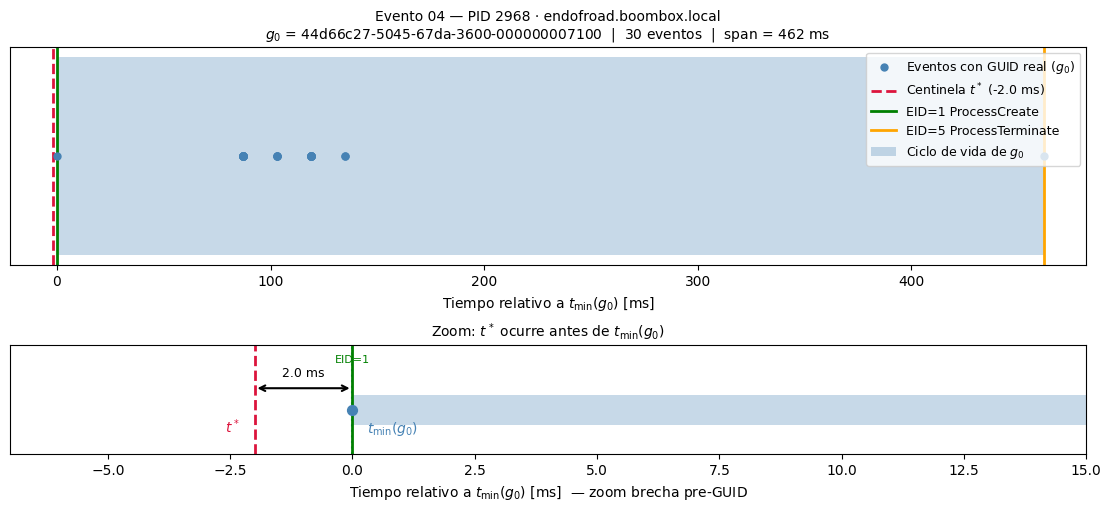

Figura guardada: ../sesion-2/img/ev04_timeline.png


In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Eventos EID=1 y EID=5 para PID 2968 en endofroad ────────────────────────
eid1_proc = df[
    (df['EventID'] == 1) &
    (df['Computer'] == c04) & (df['ProcessId'] == p04)
].sort_values('ts')

eid5_proc = df[
    (df['EventID'] == 5) &
    (df['Computer'] == c04) & (df['ProcessId'] == p04)
].sort_values('ts')

print(f'EID=1 (ProcessCreate)   para PID {int(p04)}: {len(eid1_proc)} evento(s)')
print(f'EID=5 (ProcessTerminate) para PID {int(p04)}: {len(eid5_proc)} evento(s)')
if len(eid1_proc): print(eid1_proc[['ts','ProcessGuid','Image']].to_string(index=False))
if len(eid5_proc): print(eid5_proc[['ts','ProcessGuid','Image']].to_string(index=False))

# ── Offsets en ms relativos a t_min_g0 ──────────────────────────────────────
origin    = t_min_g0
t_star_ms = (t_star   - origin).total_seconds() * 1000
t_min_ms  = 0.0
t_max_ms  = (t_max_g0 - origin).total_seconds() * 1000
ev_ms     = [(t - origin).total_seconds() * 1000 for t in g0_events['ts']]

eid1_ms = [(t - origin).total_seconds() * 1000 for t in eid1_proc['ts']]
eid5_ms = [(t - origin).total_seconds() * 1000 for t in eid5_proc['ts']]

fig, axes = plt.subplots(2, 1, figsize=(11, 5),
                         gridspec_kw={'height_ratios': [2, 1]},
                         constrained_layout=True)

# ── Panel superior: vista completa ───────────────────────────────────────────
ax = axes[0]
ax.barh(0, t_max_ms - t_min_ms, left=t_min_ms, height=0.35,
        color='steelblue', alpha=0.3, label='Ciclo de vida de $g_0$')
ax.scatter(ev_ms, [0]*len(ev_ms), color='steelblue', s=25, zorder=3,
           label='Eventos con GUID real ($g_0$)')
ax.axvline(t_star_ms, color='crimson', linewidth=2, linestyle='--',
           label=f'Centinela $t^*$ ({t_star_ms:.1f} ms)')

# EID=1 y EID=5
for x in eid1_ms:
    ax.axvline(x, color='green', linewidth=2, linestyle='-',
               label='EID=1 ProcessCreate' if x == eid1_ms[0] else '_')
for x in eid5_ms:
    ax.axvline(x, color='orange', linewidth=2, linestyle='-',
               label='EID=5 ProcessTerminate' if x == eid5_ms[0] else '_')

ax.set_xlabel('Tiempo relativo a $t_{\\min}(g_0)$ [ms]')
ax.set_yticks([])
ax.set_title(
    f'Evento 04 — PID 2968 · endofroad.boombox.local\n'
    f'$g_0$ = {g0}  |  {len(g0_events)} eventos  |  span = {t_max_ms:.0f} ms',
    fontsize=10
)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(t_star_ms - 20, t_max_ms + 20)

# ── Panel inferior: zoom en la brecha pre-GUID ───────────────────────────────
ax2 = axes[1]
zoom_lo, zoom_hi = t_star_ms - 5, t_min_ms + 15
ax2.barh(0, t_max_ms - t_min_ms, left=t_min_ms, height=0.35,
         color='steelblue', alpha=0.3)
ax2.scatter([ev_ms[0]], [0], color='steelblue', s=50, zorder=3)
ax2.axvline(t_star_ms, color='crimson', linewidth=2, linestyle='--')
ax2.axvline(t_min_ms,  color='steelblue', linewidth=1.5, linestyle=':')

# EID=1 y EID=5 en el zoom (solo si caen en la ventana)
for x in eid1_ms:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color='green', linewidth=2)
        ax2.text(x, 0.55, 'EID=1', ha='center', fontsize=8, color='green')
for x in eid5_ms:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color='orange', linewidth=2)
        ax2.text(x, 0.55, 'EID=5', ha='center', fontsize=8, color='orange')

ax2.annotate('', xy=(t_min_ms, 0.25), xytext=(t_star_ms, 0.25),
             arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax2.text((t_star_ms + t_min_ms) / 2, 0.35,
         f'{abs(t_star_ms):.1f} ms', ha='center', va='bottom', fontsize=9)
ax2.text(t_star_ms - 0.3, -0.25, '$t^*$', ha='right', color='crimson', fontsize=10)
ax2.text(t_min_ms  + 0.3, -0.25, '$t_{\\min}(g_0)$', ha='left',
         color='steelblue', fontsize=10)
ax2.set_xlim(zoom_lo, zoom_hi)
ax2.set_ylim(-0.5, 0.75)
ax2.set_yticks([])
ax2.set_xlabel('Tiempo relativo a $t_{\\min}(g_0)$ [ms]  — zoom brecha pre-GUID')
ax2.set_title('Zoom: $t^*$ ocurre antes de $t_{\\min}(g_0)$', fontsize=10)

OUT = '../sesion-2/img/ev04_timeline.png'
fig.savefig(OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {OUT}')

### Análisis del evento centinela EID=7

El evento centinela es un **ImageLoad (EID=7)** — Sysmon registra la carga
de `conhost.exe` como imagen ejecutable del proceso. Examinamos todos sus campos
y evaluamos dos hipótesis sobre su propiedad:

- **H1 (auto-carga durante inicialización):** el EID=7 registra la carga de la
  propia imagen de `conhost.exe` en el momento en que el proceso se está
  inicializando. El driver de Sysmon interceptó este evento antes de terminar de
  asignar el GUID (artefacto pre-GUID). El proceso propietario es PID 2968 = $g_0$.
- **H2 (carga por proceso externo):** otro proceso —con GUID centinela propio—
  cargó `conhost.exe` como módulo antes de que existiera el proceso PID 2968.
  En ese caso el GUID correcto no sería $g_0$ sino el del proceso externo.


In [24]:
# Todos los campos del evento centinela e*
print('=== Evento centinela e* — todos los campos ===')
non_null = ev04.dropna()
print(non_null.to_string())

=== Evento centinela e* — todos los campos ===
_original_row_index                                                                      19619
_row_hash                                                                            h3020ee25
EventID                                                                                      7
Computer                                                               endofroad.boombox.local
ProcessGuid                                               00000000-0000-0000-0000-000000000000
ProcessId                                                                               2968.0
Image                                                          C:\Windows\System32\conhost.exe
User                                                                       NT AUTHORITY\SYSTEM
Hashes                 SHA256=32C93F26B1B3DEC2BFCEE6F320AE77615A90AF96C66DE2846BDC8F64165754AA
ImageLoaded                                                    C:\Windows\System32\conhost.exe
Ori

In [ ]:
# Proceso creador de conhost.exe: quién lo creó (desde el EID=1)
print('=== EID=1 de conhost.exe (PID 2968) — proceso padre ===')
cols_eid1 = ['ts','ProcessGuid','ProcessId','Image',
             'ParentProcessGuid','ParentProcessId','ParentImage',
             'CommandLine','User']
print(eid1_proc[[c for c in cols_eid1 if c in eid1_proc.columns]].to_string(index=False))

=== EID=1 de conhost.exe (PID 2968) — proceso padre ===
                     ts                          ProcessGuid  ProcessId                           Image                    ParentProcessGuid  ParentProcessId                      ParentImage                                             CommandLine                User
2025-03-19 05:04:05.552 44d66c27-5045-67da-3600-000000007100     2968.0 C:\Windows\System32\conhost.exe 44d66c27-5045-67da-3500-000000007100           2668.0 C:\Windows\System32\dsregcmd.exe \??\C:\Windows\system32\conhost.exe 0xffffffff -ForceV1 NT AUTHORITY\SYSTEM


In [26]:
# Nota: todos los eventos de esta ventana comparten el mismo milisegundo
# (1742360645550). Fueron capturados en el mismo batch de ETW, lo que
# confirma que la densidad de actividad en endofroad fue muy alta en ese
# instante, pero no aporta información direccional sobre la propiedad del
# evento centinela.
# Ventana temporal ±10 ms alrededor de t*: qué más ocurrió en endofroad
DELTA_MS = 10
t_lo = t_star - pd.Timedelta(milliseconds=DELTA_MS)
t_hi = t_star + pd.Timedelta(milliseconds=DELTA_MS)

window = (
    df[(df['Computer'] == c04) & (df['ts'] >= t_lo) & (df['ts'] <= t_hi)]
    .sort_values('ts')
    [['ts','EventID','ProcessGuid','ProcessId','Image','User',
      'SourceIp','SourcePort','DestinationIp','DestinationPort']]
)
window['▶'] = ''
window.loc[window['ProcessId'] == p04, '▶'] = '◀ PID 2968'

print(f'Eventos en endofroad en ventana t* ± {DELTA_MS} ms:')
display(window.reset_index(drop=True))

Eventos en endofroad en ventana t* ± 10 ms:


,ts,EventID,ProcessGuid,ProcessId,Image,User,SourceIp,SourcePort,DestinationIp,DestinationPort,▶
0,2025-03-19 05:04:05.550,7,44d66c27-5043-67da-1f00-000000007100,1552.0,C:\Windows\System32\svchost.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
1,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
2,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
3,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
4,2025-03-19 05:04:05.550,7,44d66c27-5044-67da-3200-000000007100,2488.0,C:\Windows\System32\sppsvc.exe,NT AUTHORITY\NETWORK SERVICE,NaN,NaN,NaN,NaN,
5,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
6,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
7,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
8,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
9,2025-03-19 05:04:05.550,12,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,


In [27]:
# ¿El proceso padre (ParentProcessId) tiene eventos propios en esa ventana?
parent_pid = eid1_proc['ParentProcessId'].iloc[0] if len(eid1_proc) else None
parent_img = eid1_proc['ParentImage'].iloc[0]      if len(eid1_proc) else None

print(f'Proceso padre de conhost.exe: PID={parent_pid}, Image={parent_img}')
print()

if parent_pid:
    parent_events = (
        df[(df['Computer'] == c04) &
           (df['ProcessId'] == parent_pid) &
           (df['ts'] >= t_lo) & (df['ts'] <= t_hi)]
        .sort_values('ts')
        [['ts','EventID','ProcessGuid','ProcessId','Image',
          'SourceIp','SourcePort','DestinationIp','DestinationPort']]
    )
    print(f'Eventos del proceso padre (PID {int(parent_pid)}) en ventana t* ± {DELTA_MS} ms:')
    if len(parent_events):
        display(parent_events.reset_index(drop=True))
    else:
        print('  Ninguno en esa ventana.')

Proceso padre de conhost.exe: PID=2668.0, Image=C:\Windows\System32\dsregcmd.exe

Eventos del proceso padre (PID 2668) en ventana t* ± 10 ms:
  Ninguno en esa ventana.


---
### H1 vs H2: evidencia desde los datos

Para decidir entre las dos hipótesis examinamos tres piezas de evidencia:

1. **`ImageLoaded`**: si el campo contiene `conhost.exe` (mismo ejecutable que
   `Image`), estamos ante una auto-carga → señal fuerte de H1.
2. **Usuario**: si coincide con el del EID=1 de PID 2968, apoya H1.
3. **Ausencia de proceso alternativo**: si no existe ningún otro proceso con
   PID 2968 en `endofroad` en el instante $t^*$, H2 no tiene soporte.


In [ ]:
# Evidencia 1: ImageLoaded del evento centinela
print('=== Campos ImageLoad del evento centinela ===')
print(f"Image       : {ev04.get('Image', 'N/A')}")
print(f"ImageLoaded : {ev04.get('ImageLoaded', 'N/A')}")
print(f"User        : {ev04.get('User', 'N/A')}")
print()

# Auto-carga: Image == ImageLoaded
auto_load = str(ev04.get('Image','')).lower() == str(ev04.get('ImageLoaded','')).lower()
print(f'Image == ImageLoaded (auto-carga): {auto_load}')
print()

# Evidencia 2: usuario del EID=1 de g0
user_eid1 = eid1_proc['User'].iloc[0] if len(eid1_proc) else 'N/A'
user_sent  = ev04.get('User', 'N/A')
print(f'User en EID=1 (g0) : {user_eid1}')
print(f'User en centinela  : {user_sent}')
print(f'Coinciden          : {str(user_eid1).lower() == str(user_sent).lower()}')
print()

# Evidencia 3: ¿hay otro proceso con PID 2968 antes de t*?
otros_pid = df[
    (df['Computer'] == c04) &
    (df['ProcessId'] == p04) &
    (df['ts'] < t_star) &
    (df['ProcessGuid'] != NULL_GUID)
]
print(f'Eventos con PID {int(p04)} y GUID real ANTES de t*: {len(otros_pid)}')
if len(otros_pid):
    print(otros_pid[['ts','EventID','ProcessGuid','Image']].head())
else:
    print('  → Ninguno. No hay evidencia de un proceso previo con PID 2968.')


### Conclusión: H1 confirmada — `REPLACE_GUID` con extensión δ

Las tres evidencias apuntan inequívocamente a **H1**:

| Evidencia | Resultado |
|-----------|-----------|
| `ImageLoaded == Image` (auto-carga) | ✓ `conhost.exe` carga su propia imagen |
| Usuario idéntico en centinela y EID=1 | ✓ `NT AUTHORITY\SYSTEM` en ambos |
| Sin proceso previo con PID 2968 y GUID real | ✓ No existe candidato alternativo para H2 |

**Mecanismo (H1):** durante la inicialización de `conhost.exe`, el kernel
notifica a Sysmon la carga de la imagen ejecutable (EID=7) antes de que el
driver haya procesado el EID=1 y asignado el GUID al proceso. El resultado
es un evento centinela que precede a $t_{\min}(g_0)$ por exactamente **2 ms**
— la ventana en que el GUID aún no estaba disponible.

La regla de recuperación queda confirmada para este evento:

$$
t_{\min}(g_0) - \delta \leq t^* \quad (\delta = 2\,\text{ms}) \implies \texttt{REPLACE\_GUID}
$$

$g_0 =$ `44d66c27-5045-67da-3600-000000007100` es el GUID correcto para el evento centinela.
